In [1]:
NUM_AGENTS = 1
HEIGHT = 4
WIDTH = 4
SPAWN_PROB_PER_CELL = 0.05
DESPAWN_PROB_PER_CELL = 0.09

# Parameters
ENV_ITERATIONS = 100000
DISCOUNT = 0.99
EPSILON = 0.1
LEARNING_RATE = 0.00002
BATCH_SIZE = 32


HIDDEN_FEATURES = 128
HIDDEN_LAYERS = 4

In [2]:
import sys
sys.path.append("../..")
from models.value_cnn import ValueCNNCentralized
import numpy as np
from orchard.environment import Action2D, OrchardBasic
from tqdm import tqdm
import torch
from scipy.stats import norm
import copy
import numpy as np
import torch
import matplotlib.pyplot as plt

from models.value_cnn import Transition
from utils import ten_float
from dataclasses import dataclass
from typing import Any


--- PyTorch is configured to use: cuda ---


In [3]:

@dataclass
class Position:
    row: int
    col: int
    def np_array(self):
        return np.array([self.row, self.col])

@dataclass
class State:
    apples: np.ndarray[Any, np.dtype[np.int_]]
    agents: np.ndarray[Any, np.dtype[np.int_]]
    name: str = "State"
    def __hash__(self):
        # Convert the numpy arrays to their byte representation, which is hashable
        return hash((self.agents.tobytes(), self.apples.tobytes()))

    def __eq__(self, other):
        # Define how to check for equality between two State objects
        return np.array_equal(self.agents, other.agents) and np.array_equal(self.apples, other.apples)
    def copy(self):
        return State(apples=self.apples.copy(), agents=self.agents.copy(), name=self.name)

In [4]:
def simulate_step(s: State, agent_idx: int, agent_positions: np.ndarray, action_vector: np.ndarray):
    """
    Simulates an agent taking an action. Does not modify in place.
    
    Returns:
        tuple: (reward: int, next_state: State, new_agent_positions: np.ndarray)
    """
    current_agents = s.agents
    current_apples = s.apples
    agent_pos = agent_positions[agent_idx]
    grid_shape = current_agents.shape
    
    new_position = np.clip(
        agent_pos + action_vector, [0, 0], np.array(grid_shape) - 1
    )
    
    next_agents = current_agents.copy()
    next_apples = current_apples.copy()
    
    next_agents[tuple(new_position)] += 1
    next_agents[tuple(agent_pos)] -= 1
    
    # The new positions array must be updated
    new_agent_positions = agent_positions.copy()
    new_agent_positions[agent_idx] = new_position
    
    reward = 0
    if next_apples[tuple(new_position)] > 0:
        next_apples[tuple(new_position)] -= 1
        reward = 1
        
    return reward, State(apples=next_apples, agents=next_agents), new_agent_positions

### Get CNN Centralized Estimate Value

In [5]:
history = {
    "loss": [],
    "reward_mean": [],
    "reward_std": [],
    "target_mean": [],
    "target_std": [],
    "pred_mean": [],
    "pred_std": [],
    "corr": [],
}

def log_batch_stats(net: ValueCNNCentralized, batch_size: int):
    """Compute and store one-line summary statistics based on a sample from the replay buffer."""
    with torch.no_grad():
        if len(net.memory) < batch_size:
            return
            
        device = next(net.parameters()).device

        transitions = net.memory.sample(batch_size)
        batch = Transition(*zip(*transitions))

        states = ten_float(np.stack(batch.state), device=device)
        next_states = ten_float(np.stack(batch.new_state), device=device)
        rewards = ten_float(np.array(batch.reward), device=device)

        preds = net.forward(states).squeeze(1)
        
        # CORRECTED: use net.discount instead of net.trainer.discount
        targets = rewards + net.discount * net.target_net(next_states).squeeze(1)

        preds_np, targets_np, rewards_np = preds.cpu().numpy(), targets.cpu().numpy(), rewards.cpu().numpy()
        corr = np.corrcoef(preds_np, targets_np)[0, 1] if len(preds_np) > 1 else np.nan

    history["reward_mean"].append(np.mean(rewards_np))
    history["reward_std"].append(np.std(rewards_np))
    history["target_mean"].append(np.mean(targets_np))
    history["target_std"].append(np.std(targets_np))
    history["pred_mean"].append(np.mean(preds_np))
    history["pred_std"].append(np.std(preds_np))
    history["corr"].append(corr)
def state_to_raw_dict(s: State) -> dict:
    return {"apples": s.apples, "agents": s.agents}



In [6]:
def spawn_apples(s: State):
    p_cell = SPAWN_PROB_PER_CELL
    H, L = s.apples.shape  # ★ rows = width, cols = length

    rand_mat = np.random.rand(H, L)  # ★ new RNG draw, same shape
    spawn_mask = rand_mat < p_cell
    spawn_mask = spawn_mask & (
        s.agents == 0
    )  # KEY CHANGE: only spawn where there are no agents.
    s.apples[spawn_mask] += 1
    return s

def despawn_apples(s: State):
    """
    One 'second-boundary' update:
      • despawn apples with geom-hazard q = 1/T
      • spawn new apples in empty cells with p_cell = r · s_target
    Call exactly once after every n micro-ticks.
    """
    q_despawn = DESPAWN_PROB_PER_CELL
    H, L = s.apples.shape  # ★ rows = width, cols = length

    # ---- despawn ----
    rand_mat = np.random.rand(H, L)  # ★ same shape as s.apples
    mask_apples = s.apples != 0
    removal_mask = mask_apples & (rand_mat < q_despawn)
    s.apples[removal_mask] -= 1
    return removal_mask.sum()

def init_empty_state():
    return State(
        apples=np.zeros((HEIGHT, WIDTH), dtype=int),
        agents=np.zeros((HEIGHT, WIDTH), dtype=int),
        name="Empty State",
    )

def place_agents_randomly(s: State, num_agents: int):
    H, L = s.agents.shape
    empty_positions = np.argwhere(s.agents == 0)
    chosen_indices = np.random.choice(len(empty_positions), size=num_agents, replace=False)
    for index in chosen_indices:
        pos = empty_positions[index]
        s.agents[tuple(pos)] = 1
    return s

In [7]:
s_0 = init_empty_state()
place_agents_randomly(s_0, NUM_AGENTS)
agent_positions = np.argwhere(s_0.agents == 1)

In [8]:
NUM_TO_AVERAGE_OVER = 100
# use monte carlo to calculate true state values
state = s_0.copy()
state.name = "Single Agent Empty State"

total_values = []
initial_agent_positions = np.argwhere(state.agents == 1)
for n in tqdm(range(NUM_TO_AVERAGE_OVER), desc=f"iterating over {state.name}"):
    agent_positions = initial_agent_positions.copy()
    s_t = state
    total_value = 0
    discount_factor = 1.0
    for t in range(1000):
        c = np.random.randint(0, NUM_AGENTS)
        action = Action2D.get_random_action()
        
        r_t, s_t_plus_1, agent_positions = simulate_step(s_t, c, agent_positions, action.vector)   
        spawn_apples(s_t_plus_1)
        despawn_apples(s_t_plus_1)
        
        total_value += discount_factor * r_t
        discount_factor *= DISCOUNT
        s_t = s_t_plus_1
    total_values.append(total_value)
avg_value = np.mean(total_values)
print(f"Estimated true value of state:\n{state.name}\n is approximately: {avg_value}\n")

iterating over Single Agent Empty State: 100%|██████████| 100/100 [00:02<00:00, 46.03it/s]

Estimated true value of state:
Single Agent Empty State
 is approximately: 17.917130070617006



In [9]:
value_CNN_centralized = ValueCNNCentralized(HEIGHT, WIDTH, LEARNING_RATE, DISCOUNT, HIDDEN_FEATURES, HIDDEN_LAYERS)
s_0 = init_empty_state()
place_agents_randomly(s_0, NUM_AGENTS)
agent_positions = np.argwhere(s_0.agents == 1)

NUM_EPOCHS = 500
NUM_ITER = 200
initial_agent_positions = agent_positions.copy()
TARGET_UPDATE_FREQUENCY = 100
total_steps = 0

for epoch in tqdm(range(NUM_EPOCHS)):
    agent_positions = initial_agent_positions.copy()
    s_t = s_0.copy()
    for t in range(NUM_ITER):
        c = np.random.randint(0, len(agent_positions))
        action = Action2D.get_random_action()
            
        r_t, s_intermediate, agent_positions = simulate_step(s_t, c, agent_positions, action.vector)
        s_t_plus_1 = s_intermediate.copy()
        spawn_apples(s_t_plus_1)
        despawn_apples(s_t_plus_1)
        
        # 1. Convert states to the network input format
        processed_s_t = value_CNN_centralized.raw_state_to_nn_input(state_to_raw_dict(s_t))
        processed_s_t_plus_1 = value_CNN_centralized.raw_state_to_nn_input(state_to_raw_dict(s_t_plus_1))

        # 2. Add the experience to the replay buffer
        value_CNN_centralized.add_experience(processed_s_t, processed_s_t_plus_1, r_t)

        # 3. Train on a batch ONLY if the buffer is large enough
        if len(value_CNN_centralized.memory) >= BATCH_SIZE:
            log_batch_stats(value_CNN_centralized, BATCH_SIZE)
            value_CNN_centralized.train_batch(BATCH_SIZE)
        
        # 4. Periodically update the target network
        if total_steps % TARGET_UPDATE_FREQUENCY == 0:
            value_CNN_centralized.update_target_net()

        s_t = s_t_plus_1
        total_steps += 1


100%|██████████| 500/500 [10:54<00:00,  1.31s/it]


In [10]:
state = s_0.copy()
raw_state = {"apples": state.apples, "agents": state.agents}
predicted_value = value_CNN_centralized.get_model_reward_prediction_from_raw(raw_state)
print(f"Predicted value of state {state.name} by trained CNN: {predicted_value.item()}")

Predicted value of state Empty State by trained CNN: 18.437015533447266


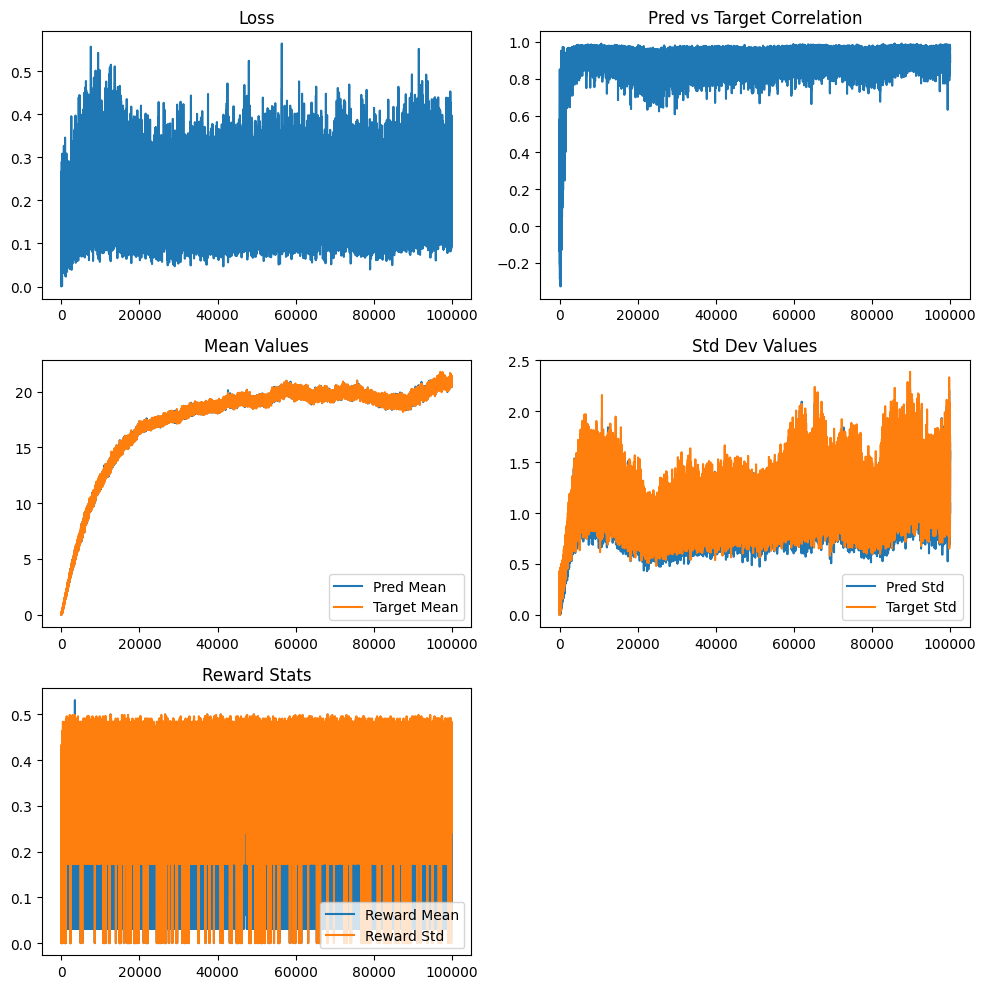

In [11]:
def plot_training_diagnostics(value_CNN_centralized):
    fig, axs = plt.subplots(3, 2, figsize=(10, 10))
    axs = axs.flatten()

    axs[0].plot(value_CNN_centralized.loss_history)
    axs[0].set_title("Loss")

    axs[1].plot(history["corr"])
    axs[1].set_title("Pred vs Target Correlation")

    axs[2].plot(history["pred_mean"], label="Pred Mean")
    axs[2].plot(history["target_mean"], label="Target Mean")
    axs[2].set_title("Mean Values")
    axs[2].legend()

    axs[3].plot(history["pred_std"], label="Pred Std")
    axs[3].plot(history["target_std"], label="Target Std")
    axs[3].set_title("Std Dev Values")
    axs[3].legend()

    axs[4].plot(history["reward_mean"], label="Reward Mean")
    axs[4].plot(history["reward_std"], label="Reward Std")
    axs[4].set_title("Reward Stats")
    axs[4].legend()

    axs[5].axis("off")
    plt.tight_layout()
    plt.show()

plot_training_diagnostics(value_CNN_centralized)
